# K-Means on Cyberbullying Tweets using **BERT embeddings**

This is the BERT version of the earlier TF-IDF notebook. Instead of counting words
(TF-IDF), we turn each tweet into a **dense sentence embedding** from a pre-trained
BERT model (`all-MiniLM-L6-v2`, a Sentence-BERT model). These embeddings capture
*meaning*, not just word overlap, so semantically similar tweets sit close together
even if they use different words.

**Reminder:** K-Means is still *unsupervised*. The `age=1` / `not_cyberbullying=0`
labels are used only to *evaluate* the clusters afterward.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, confusion_matrix

sns.set_style('whitegrid')

d:\Coding Projects\Kmeans_vs_Knn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the data

In [2]:
df = pd.read_csv('cyberbullying_tweets.csv')
print('Full dataset shape:', df.shape)
print(df['cyberbullying_type'].value_counts())
df.head()

Full dataset shape: (47692, 2)
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


## 2. Keep only the two classes, remove duplicates, and label

`age -> 1`, `not_cyberbullying -> 0`.

In [3]:
df = df[df['cyberbullying_type'].isin(['age', 'not_cyberbullying'])].copy()

before = df.shape[0]
df = df.drop_duplicates()
print(f'Removed {before - df.shape[0]} duplicate rows.')

df['label'] = df['cyberbullying_type'].map({'age': 1, 'not_cyberbullying': 0})
print('Final shape:', df.shape)
df[['tweet_text', 'cyberbullying_type', 'label']].head()

Removed 8 duplicate rows.
Final shape: (15929, 3)


,tweet_text,cyberbullying_type,label
0,"In other words #katandandre, your food was cra...",not_cyberbullying,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,0
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,0
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,0


## 3. Visualize the class balance

Before modelling, always look at how balanced the classes are.

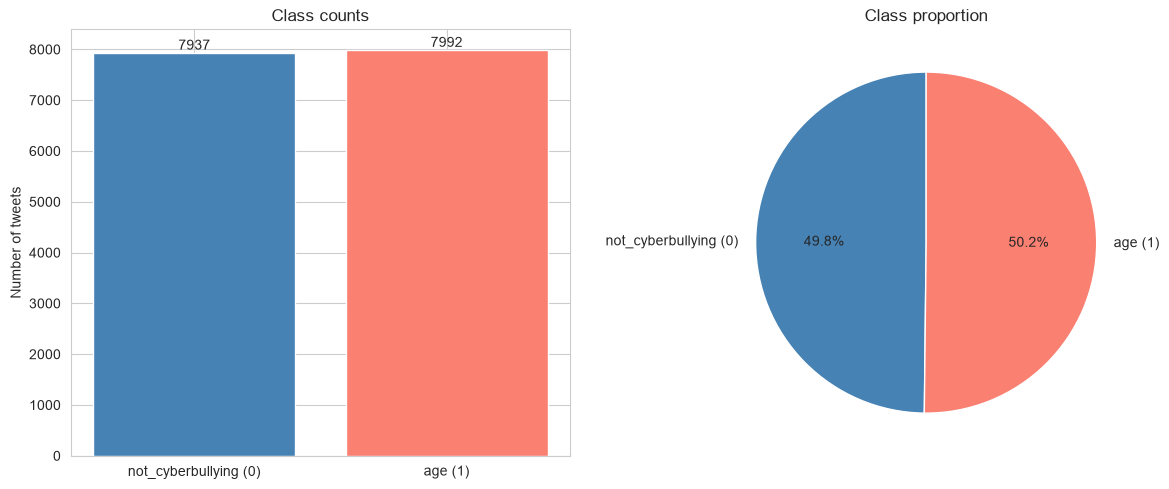

In [4]:
counts = df['label'].value_counts().sort_index()
labels_txt = ['not_cyberbullying (0)', 'age (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels_txt, counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Class counts')
axes[0].set_ylabel('Number of tweets')
for i, v in enumerate(counts.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

axes[1].pie(counts.values, labels=labels_txt, autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Class proportion')

plt.tight_layout()
plt.show()

## 4. Light text cleaning

BERT handles natural text well, so we only strip the noise: URLs and @mentions.
We keep casing and punctuation because the model uses them.

In [5]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # URLs
    text = re.sub(r'@\w+', ' ', text)                # @mentions
    text = re.sub(r'\s+', ' ', text).strip()         # collapse whitespace
    return text

df['clean_text'] = df['tweet_text'].apply(clean_text)
df[['tweet_text', 'clean_text']].head()

,tweet_text,clean_text
0,"In other words #katandandre, your food was cra...","In other words #katandandre, your food was cra..."
1,Why is #aussietv so white? #MKR #theblock #ImA...,Why is #aussietv so white? #MKR #theblock #ImA...
2,@XochitlSuckkks a classy whore? Or more red ve...,a classy whore? Or more red velvet cupcakes?
3,"@Jason_Gio meh. :P thanks for the heads up, b...","meh. :P thanks for the heads up, but not too c..."
4,@RudhoeEnglish This is an ISIS account pretend...,This is an ISIS account pretending to be a Kur...


## 5. Turn tweets into BERT embeddings

The first run downloads the model (~90 MB). Each tweet becomes a 384-dimensional vector.
This is the heavy step — it may take a couple of minutes on CPU.

In [6]:
model = SentenceTransformer('all-MiniLM-L6-v2')

X = model.encode(
    df['clean_text'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
)
print('BERT embedding matrix shape (tweets x dimensions):', X.shape)

Batches: 100%|██████████| 249/249 [01:52<00:00,  2.21it/s]


BERT embedding matrix shape (tweets x dimensions): (15929, 384)


## 6. Run K-Means with k=2

In [7]:
kmeans = KMeans(n_clusters=2, random_state=23, n_init=10)
df['cluster'] = kmeans.fit_predict(X)
print('Points per cluster:')
print(df['cluster'].value_counts())

Points per cluster:
cluster
1    8391
0    7538
Name: count, dtype: int64


## 7. Cluster sizes vs. true class sizes

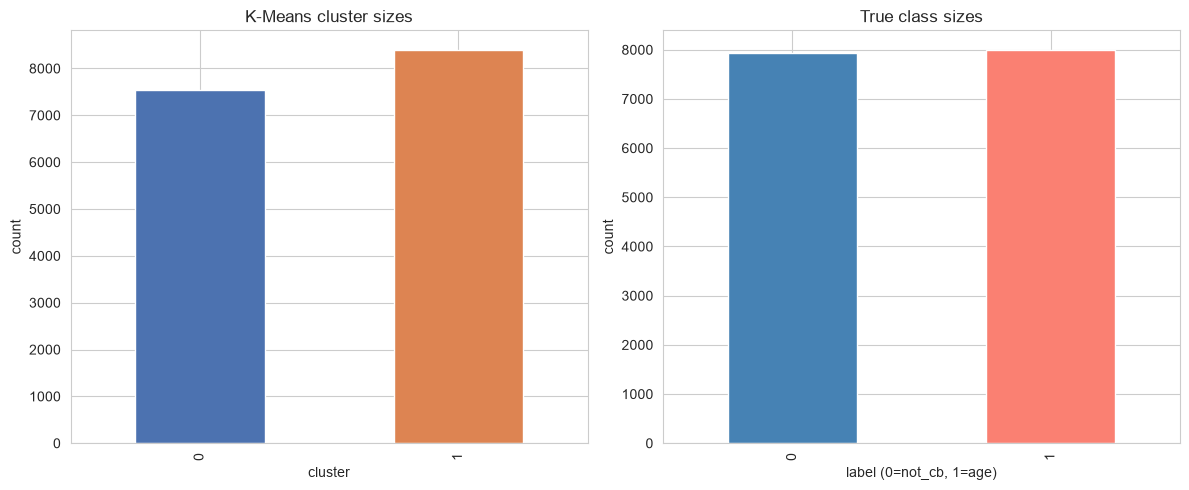

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['cluster'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#4c72b0', '#dd8452'])
axes[0].set_title('K-Means cluster sizes')
axes[0].set_xlabel('cluster')
axes[0].set_ylabel('count')

df['label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('True class sizes')
axes[1].set_xlabel('label (0=not_cb, 1=age)')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

## 8. Project embeddings to 2D with PCA and plot

Left = clusters K-Means found. Right = the real labels.

Explained variance by 2 components: 0.136


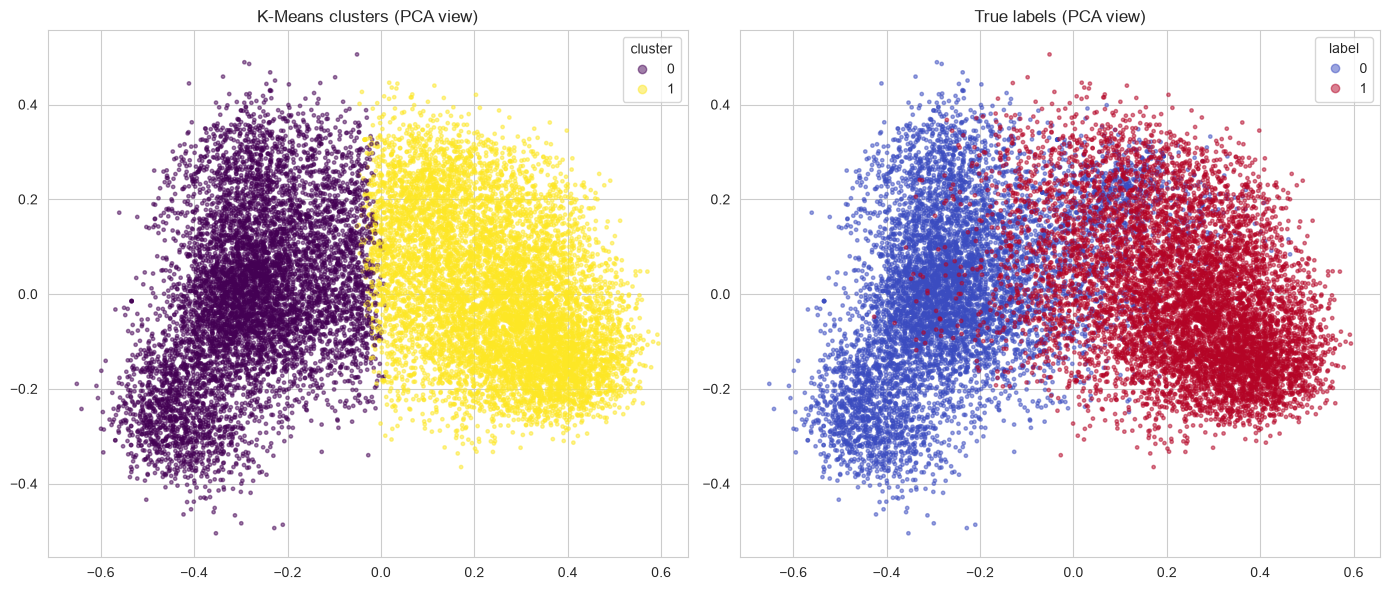

In [9]:
pca = PCA(n_components=2, random_state=23)
X_2d = pca.fit_transform(X)
print('Explained variance by 2 components:', pca.explained_variance_ratio_.sum().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc0 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=df['cluster'], cmap='viridis', s=6, alpha=0.5)
axes[0].set_title('K-Means clusters (PCA view)')
axes[0].legend(*sc0.legend_elements(), title='cluster')

sc1 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=df['label'], cmap='coolwarm', s=6, alpha=0.5)
axes[1].set_title('True labels (PCA view)')
axes[1].legend(*sc1.legend_elements(), title='label')

plt.tight_layout()
plt.show()

## 9. t-SNE view (often separates clusters more clearly)

t-SNE is slow, so we run it on a random sample of 3,000 tweets.

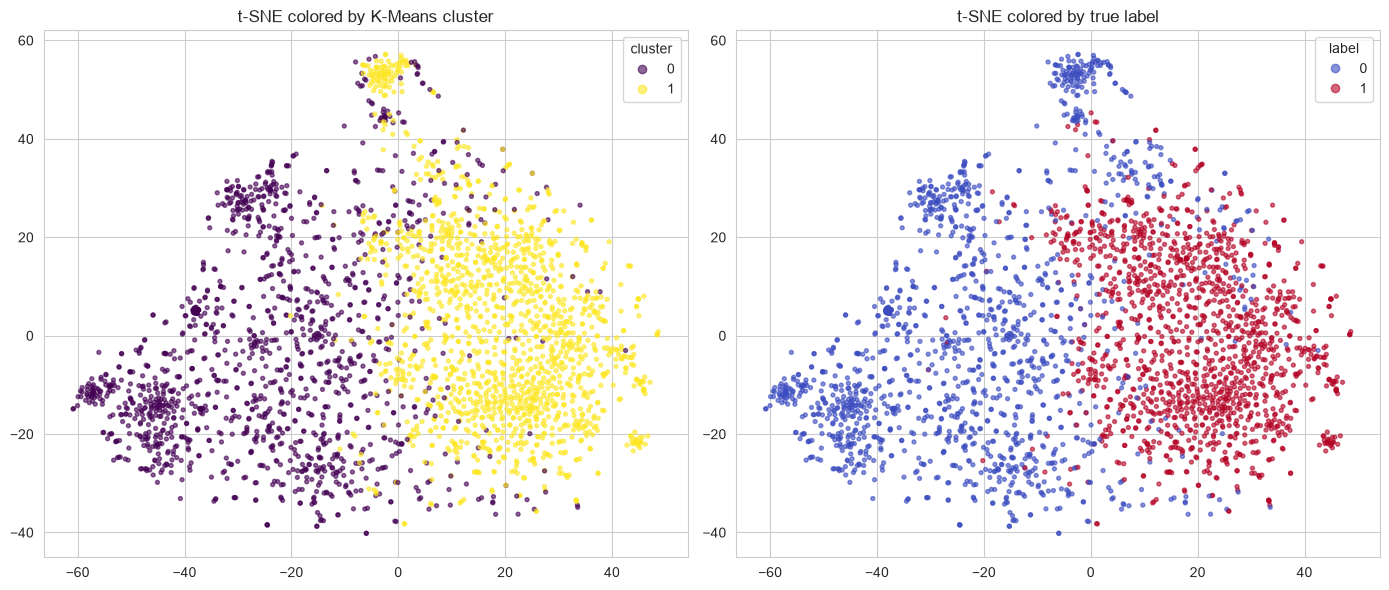

In [10]:
sample_idx = np.random.RandomState(23).choice(len(X), size=3000, replace=False)
X_sample = X[sample_idx]

tsne = TSNE(n_components=2, random_state=23, perplexity=30, init='pca')
X_tsne = tsne.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc0 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=df['cluster'].values[sample_idx], cmap='viridis', s=8, alpha=0.6)
axes[0].set_title('t-SNE colored by K-Means cluster')
axes[0].legend(*sc0.legend_elements(), title='cluster')

sc1 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=df['label'].values[sample_idx], cmap='coolwarm', s=8, alpha=0.6)
axes[1].set_title('t-SNE colored by true label')
axes[1].legend(*sc1.legend_elements(), title='label')

plt.tight_layout()
plt.show()

## 10. Confusion matrix: clusters vs. true labels

K-Means numbers clusters arbitrarily, so we first flip the cluster ids if that gives
a better match, then draw a heatmap.

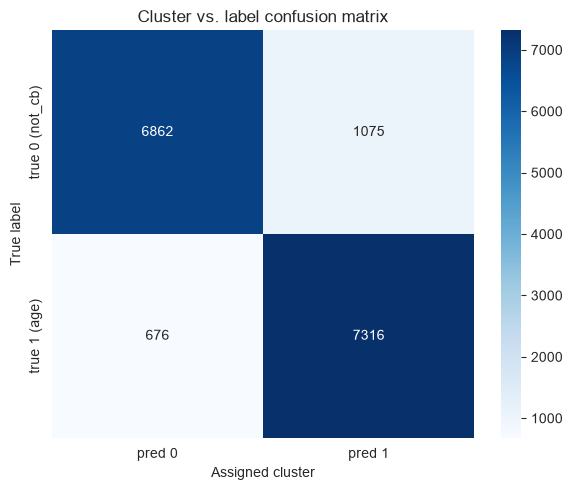

In [11]:
# Align cluster ids to labels for a fair comparison
agreement = (df['cluster'] == df['label']).mean()
if agreement < 0.5:
    df['cluster_aligned'] = 1 - df['cluster']
else:
    df['cluster_aligned'] = df['cluster']

cm = confusion_matrix(df['label'], df['cluster_aligned'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['pred 0', 'pred 1'],
            yticklabels=['true 0 (not_cb)', 'true 1 (age)'])
plt.title('Cluster vs. label confusion matrix')
plt.ylabel('True label')
plt.xlabel('Assigned cluster')
plt.tight_layout()
plt.show()

## 11. Quantitative scores

In [12]:
best_match = (df['cluster_aligned'] == df['label']).mean()
sil = silhouette_score(X, df['cluster'])

print(f'Cluster-vs-label agreement (accuracy): {best_match:.2%}')
print(f'Silhouette score (cluster separation, -1..1): {sil:.3f}')

Cluster-vs-label agreement (accuracy): 89.01%
Silhouette score (cluster separation, -1..1): 0.088


## 12. Representative tweets from each cluster

The tweets closest to each cluster centre — a quick sanity check of what each group is about.

In [13]:
centers = kmeans.cluster_centers_
for c in sorted(df['cluster'].unique()):
    members = np.where(df['cluster'].values == c)[0]
    dists = np.linalg.norm(X[members] - centers[c], axis=1)
    closest = members[np.argsort(dists)[:5]]
    print(f'\n===== Cluster {c} (size {len(members)}) — 5 most central tweets =====')
    for i in closest:
        print(' -', df['tweet_text'].values[i][:120])


===== Cluster 0 (size 7538) — 5 most central tweets =====
 - #mkr oh nooo!!!! Goodluck y'all!!!!
 - NOOOOOOOOOOOOOOO!  #MKR
 - UGGGHHHHHHHHHHHHHHHHHHHHHHH FUCK OFF #MKR
 - RT @trish2295: I'm done - won't bother with the rest of this pathetic shit show #mkr
 - TWITTER IS ABOUT TO EXPLODE!  #mkr

===== Cluster 1 (size 8391) — 5 most central tweets =====
 - This was every girl who bullied me in high school
 - I've been bullied in high school myself by other girls. I always had no friends, I used to be super quiet and hide in th
 - @all the girls who bullied me in high school, what’s up with it now
 - Anyone who doesn’t say Mean Girls was bullied in high school.
 - Were you bullied in high school by girls ?
